In [5]:
from os.path import join 

import matplotlib.pyplot as plt 
import numpy as np 
import tidy3d as td 
from tidy3d import web 
from tidy3d.plugins.resonance import ResonanceFinder

from honeycomb_hex import create_hexagonal_honeycomb_slab

In [34]:
# ── Parameters (match the Lumerical script variables) ────────────────────────
a       = 1.0     # Lattice constant (um)
R       = 20       # Hexagonal radius in unit-cell repeats
radius  = 0.225   # Disk radius (um)  — corresponds to diameter 0.45 um
z_span  = 0.22    # Slab thickness (um)
n_si    = 3.47    # Refractive index of silicon
material = td.Medium(permittivity=n_si**2)

# Twist parameters for double-layer verification
ANGLE   = 1.5     # Twist angle (degrees)
GAP     = 0.3     # Gap between the two slabs (um)

In [37]:
cyls_bottom = create_hexagonal_honeycomb_slab(
    lattice_const=a, disk_radius=radius, slab_thickness=z_span,
    hex_radius=R, twist_angle=0.0, material=material, centerz=-z_span / 2 - GAP / 2,
)
cyls_top = create_hexagonal_honeycomb_slab(
    lattice_const=a, disk_radius=radius, slab_thickness=z_span,
    hex_radius=R, twist_angle=ANGLE, material=material, centerz=z_span / 2 + GAP / 2,
)

# Build a single td.Structure from all cylinders
all_geom = td.GeometryGroup(geometries=cyls_bottom + cyls_top)
structure = td.Structure(geometry=all_geom, medium=material)

In [38]:
# sim size
lx = (R * a) * 2.0 + 4
ly = (R * a) * 2.0 + 2
lz = z_span * 2 + GAP + 2.0

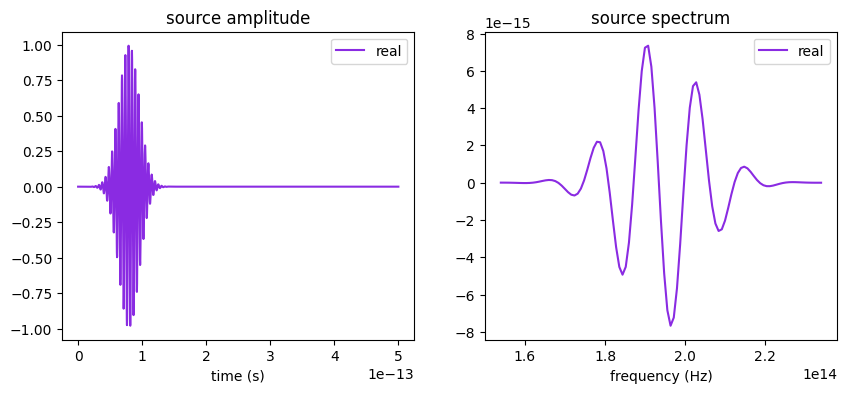

In [39]:
# Central frequency around which we'll look for the cavity mode (Hz)
wavelength = 1.55
freq0 = td.C_0 / wavelength

# Source bandwidth (Hz)
fwidth = 1e13

# Simulation run time (s)
run_time = 10e-12

# Source; plot time dependence to verify when the source pulse decayed
source = td.PointDipole(
    center=(0, 0, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    polarization="Ey",
)

# Source pulse is much shorter than the simulation run_time defined above,
# so we only examine the signal up to a shorter time = 5e-13fs
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
source.source_time.plot(np.linspace(0, 5e-13, 2000), ax=ax[0])
source.source_time.plot_spectrum(times=np.linspace(0, 5e-13, 2000), ax=ax[1])
plt.show()

In [40]:
# Starting time after the source has decayed for time series and
# for apodization of frequency domain monitors
t_start = 4e-13

# Time series monitor for Q-factor computation
time_series_mnt = td.FieldTimeMonitor(
    center=[0, 0, 0], size=[0, 0, 0], start=t_start, name="time_series"
)

# Apodization to exclude the source pulse from the frequency-domain monitors
apodization = td.ApodizationSpec(start=t_start, width=2e-13)

# near field
field_mnt = td.FieldMonitor(
    center=[0, 0, 0],
    size=[4, 2 * np.sqrt(3), 0],
    freqs=[freq0],
    name="field",
    apodization=apodization,
)

In [41]:
steps_per_unit_length = 20
grid_spec = td.GridSpec(
    grid_x=td.UniformGrid(dl=a / steps_per_unit_length),
    grid_y=td.UniformGrid(dl=a / steps_per_unit_length * np.sqrt(3) / 2),
    grid_z=td.AutoGrid(min_steps_per_wvl=steps_per_unit_length),
)

In [42]:
# Simulation
sim = td.Simulation(
    size=(lx, ly, lz),
    grid_spec=grid_spec,
    structures=[structure],
    sources=[source],
    monitors=[time_series_mnt, field_mnt],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    # symmetry=(1, -1, 1),
    shutoff=0,
)

print(f"Total number of grid points (millions): {sim.num_cells / 1e6:1.4f}")
print(f"Total number of time steps: {sim.num_time_steps}")

Total number of grid points (millions): 79.0747
Total number of time steps: 167087


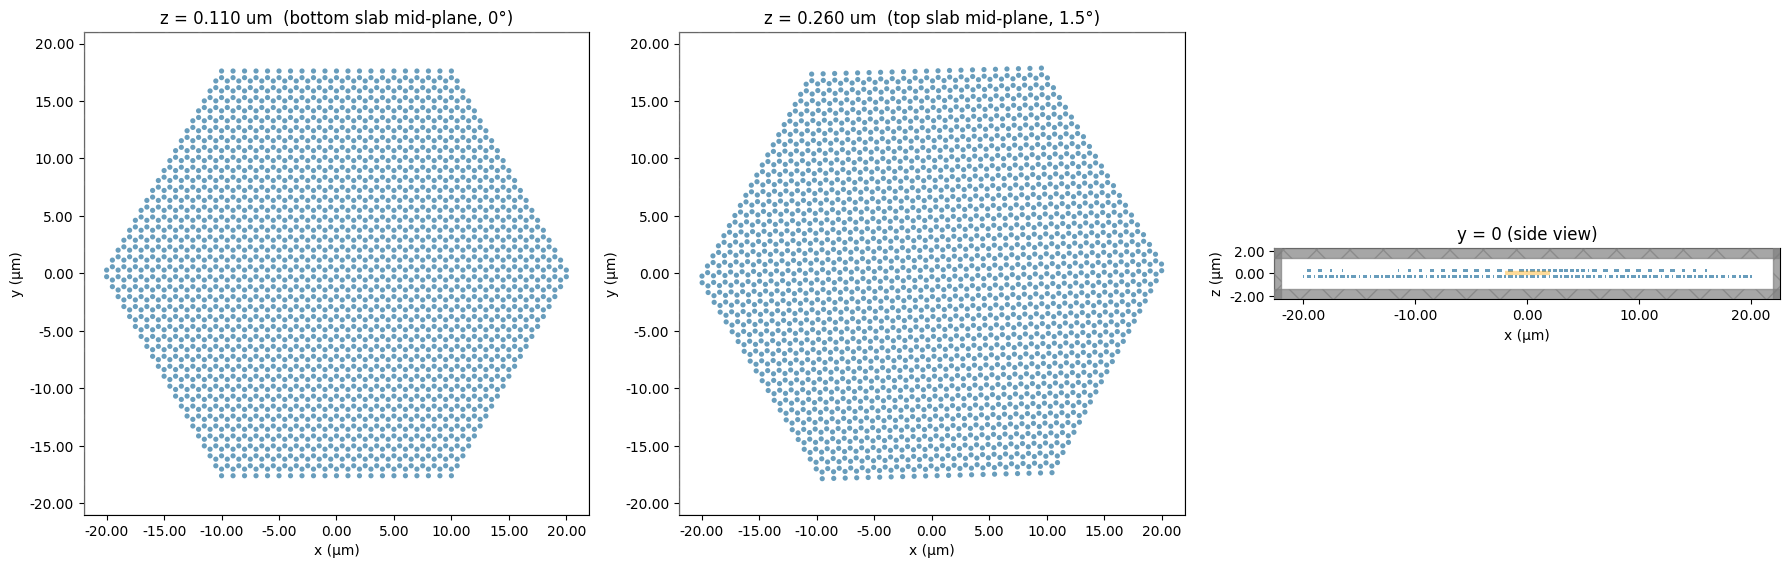

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# x-y at mid-plane of bottom slab
sim.plot(z=-z_span / 2 - GAP / 2, ax=axes[0])
axes[0].set_xlim(-lx / 2, lx / 2)
axes[0].set_ylim(-ly / 2, ly / 2)
axes[0].set_title(f"z = {z_span/2:.3f} um  (bottom slab mid-plane, 0°)")

# x-y at mid-plane of top slab
z_top_mid = z_span / 2 + GAP / 2
sim.plot(z=z_top_mid, ax=axes[1])
axes[1].set_xlim(-lx / 2, lx / 2)
axes[1].set_ylim(-ly / 2, ly / 2)
axes[1].set_title(f"z = {z_top_mid:.3f} um  (top slab mid-plane, {ANGLE}°)")

# x-z side view
sim.plot(y=0.5, ax=axes[2])
axes[2].set_title("y = 0 (side view)")

plt.tight_layout()
plt.show()

In [46]:
job = web.Job(simulation=sim, task_name="JieYao_v1", verbose=True)
estimated_cost = web.estimate_cost(job.task_id)
print(f'\n The estimated maximum cost is {estimated_cost:.3f} FlexCredits.')

18:48:05 Pacific Daylight Time Created task 'JieYao_v1' with resource_id        
                               'fdve-aff01e95-a5e7-4347-9297-fff00f02dddc' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=732710;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=538012;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\taskId]8;;\
                               ]8;id=732710;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\=]8;;\]8;id=941977;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\fdve]8;;\]8;id=732710;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\-aff01e95-a5e7-4347-9297-fff00f02dddc']8;;\.

                               Task folder: ]8;id=734043;https://tidy3d.simulation.cloud/folders/folder-401c0a0c-8e13-4a51-9b19-e6b8ae1b963e\'default']8;;\.

18:48:11 Pacific Daylight Time Estimated FlexCredit cost: 3.918. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.


 The estimated maximum cost is 3.918 FlexCredits.


In [47]:
import datetime

# job = web.Job(simulation=sim, task_name="L3_opt", verbose=True)
sim_data = job.run(path="data/JieYao_v1.hdf5")

# Log task_id to file
task_id = job.task_id
timestamp = datetime.datetime.now().isoformat()
log_entry = f"{timestamp}\ttask_name=JieYao\ttask_id={task_id}\n"
with open("data/task_log_JieYao.txt", "a") as f:
    f.write(log_entry)
print(log_entry.strip())

18:48:16 Pacific Daylight Time Estimated FlexCredit cost: 3.918. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

18:48:18 Pacific Daylight Time status = queued

                               To cancel the simulation, use                    
                               'web.abort(task_id)' or 'web.delete(task_id)' or 
                               abort/delete the task in the web UI. Terminating 
                               the Python script will not stop the job running  
                               on the cloud.

18:48:27 Pacific Daylight Time starting up solver

18:48:28 Pacific Daylight Time running solver

18:52:05 Pacific Daylight Time status = postprocess

18:52:09 Pacific Daylight Time status = success

18:52:11 Pacific Daylight Time View simulation result at                        
                               ]8;id=419980;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=105395;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\taskId]8;;\
                               ]8;id=419980;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\=]8;;\]8;id=181588;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\fdve]8;;\]8;id=419980;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc\-aff01e95-a5e7-4347-9297-fff00f02dddc']8;;\.

18:52:14 Pacific Daylight Time Loading simulation from data\JieYao_v1.hdf5

2026-03-10T18:52:15.290297	task_name=JieYao	task_id=fdve-aff01e95-a5e7-4347-9297-fff00f02dddc


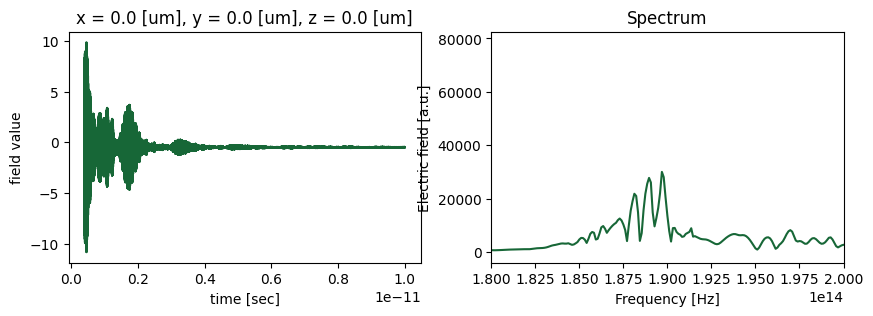

In [48]:
# Get data from the TimeMonitor
tdata = sim_data["time_series"]

time_series = tdata.Ey.squeeze()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot time dependence
time_series.plot(ax=ax1)

# Make frequency mesh and plot spectrum
dt = sim_data.simulation.dt
fmesh = np.linspace(-1 / dt / 2, 1 / dt / 2, time_series.size)
spectrum = np.fft.fftshift(np.fft.fft(time_series))

ax2.plot(fmesh, np.abs(spectrum))
ax2.set_xlim(1.8e14, 2e14)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Electric field [a.u.]")
ax2.set_title("Spectrum")
plt.show()

In [49]:
resonance_finder = ResonanceFinder(freq_window=(1.8e14, 2e14), init_num_freqs=100)
resonance_data = resonance_finder.run(sim_data["time_series"])
resonance_data.to_dataframe()

,decay,Q,amplitude,phase,error
freq,,,,,
5.304514e+06,3.216664e+08,0.051807,0.496068,-3.141259,0.000497
1.796173e+14,9.344064e+12,60.389624,0.414608,-1.280265,0.029370
1.833483e+14,2.056163e+12,280.136227,0.217935,2.508119,0.009487
1.838342e+14,1.528819e+12,377.763497,0.139605,0.913287,0.008041
1.844360e+14,7.794786e+11,743.346676,0.022111,-2.698283,0.009724
1.850101e+14,1.054349e+12,551.265487,0.111937,1.517323,0.007496
1.853772e+14,7.143402e+11,815.269472,0.077563,-1.263249,0.004553
1.855633e+14,8.038177e+11,725.244634,0.101496,1.482339,0.004905
1.858404e+14,4.442273e+11,1314.270476,0.055196,-2.026147,0.004586


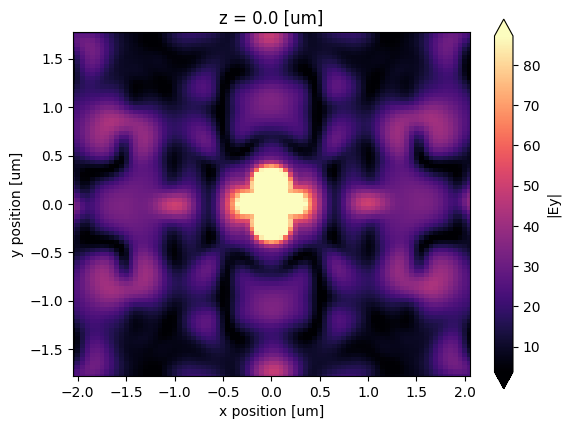

In [50]:
fig, ax = plt.subplots(1)
sim_data.plot_field("field", "Ey", val="abs", z=0, ax=ax, eps_alpha=0)
plt.show()